In [93]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
np.set_printoptions(threshold=np.inf)

In [94]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')
#df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
#df['DATE']=pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)

In [95]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2

temp=df['Temp']
#print(temp.isna().sum())
temp = temp.ffill()
#print(temp.isna().sum())
print(max(temp))


94.0


In [96]:
def seq2seq_data(df, window_size=60, horizon=30):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size-horizon):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=[[a] for a in df_as_np[i+window_size:i+window_size+horizon]]
        y.append(label)
    return np.array(X), np.array(y)

HORIZON=7
WINDOW_SIZE=30
X, y =seq2seq_data(temp, WINDOW_SIZE, HORIZON)
X.shape, y.shape

((56208, 30, 1), (56208, 7, 1))

In [97]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape
print(X_test)

[[[14. ]
  [28.5]
  [29.5]
  [24. ]
  [21.5]
  [28.5]
  [39. ]
  [31.5]
  [20. ]
  [24. ]
  [27. ]
  [32.5]
  [31. ]
  [30.5]
  [23.5]
  [39. ]
  [43.5]
  [29.5]
  [23.5]
  [17.5]
  [23.5]
  [39. ]
  [48. ]
  [39. ]
  [42.5]
  [55. ]
  [50.5]
  [37.5]
  [34.5]
  [35. ]]

 [[28.5]
  [29.5]
  [24. ]
  [21.5]
  [28.5]
  [39. ]
  [31.5]
  [20. ]
  [24. ]
  [27. ]
  [32.5]
  [31. ]
  [30.5]
  [23.5]
  [39. ]
  [43.5]
  [29.5]
  [23.5]
  [17.5]
  [23.5]
  [39. ]
  [48. ]
  [39. ]
  [42.5]
  [55. ]
  [50.5]
  [37.5]
  [34.5]
  [35. ]
  [34. ]]

 [[29.5]
  [24. ]
  [21.5]
  [28.5]
  [39. ]
  [31.5]
  [20. ]
  [24. ]
  [27. ]
  [32.5]
  [31. ]
  [30.5]
  [23.5]
  [39. ]
  [43.5]
  [29.5]
  [23.5]
  [17.5]
  [23.5]
  [39. ]
  [48. ]
  [39. ]
  [42.5]
  [55. ]
  [50.5]
  [37.5]
  [34.5]
  [35. ]
  [34. ]
  [32. ]]

 [[24. ]
  [21.5]
  [28.5]
  [39. ]
  [31.5]
  [20. ]
  [24. ]
  [27. ]
  [32.5]
  [31. ]
  [30.5]
  [23.5]
  [39. ]
  [43.5]
  [29.5]
  [23.5]
  [17.5]
  [23.5]
  [39. ]
  [48. ]
  [3

In [98]:
from tensorflow.keras.models import Model              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [99]:
encoder_inputs=Input(shape=(WINDOW_SIZE, 1))
encoder=LSTM(128, return_state=True)
encoder_output, state_h, state_c=encoder(encoder_inputs)
encoder_states=[state_h, state_c]

In [100]:
decoder_inputs=RepeatVector(HORIZON)(encoder_output)
decoder_lstm=LSTM(128, return_sequences=True)
decoder_outputs=decoder_lstm(decoder_inputs, initial_state=encoder_states)

In [101]:
decoder_outputs=TimeDistributed(Dense(1))(decoder_outputs)

In [102]:
model2=Model(encoder_inputs, decoder_outputs)
model2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ [(None, 128),     │     66,560 │ input_layer_4[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_4     │ (None, 7, 128)    │          0 │ lstm_8[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 7, 128)    │    131,584 │ repeat_vector_4[… │
│                     │                   │            │ lstm_8[0][1],     │
│                     │                   │            │ lstm_8[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 7, 1)      │        129 │ lstm_9[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
cp=ModelCheckpoint('model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [104]:
model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, callbacks=[cp])

Epoch 1/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 1399.2750 - root_mean_squared_error: 37.4069 - val_loss: 874.2977 - val_root_mean_squared_error: 29.5685
Epoch 2/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 574.1177 - root_mean_squared_error: 23.9608 - val_loss: 388.1446 - val_root_mean_squared_error: 19.7014
Epoch 3/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 255.6371 - root_mean_squared_error: 15.9887 - val_loss: 174.9045 - val_root_mean_squared_error: 13.2251
Epoch 4/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 120.9490 - root_mean_squared_error: 10.9977 - val_loss: 91.5991 - val_root_mean_squared_error: 9.5707
Epoch 5/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 74.1861 - root_mean_squared_error: 8.6131 - val_loss: 65.7034 - val_root_mean_squared_error: 8.1058
Epoch 6/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 62.3020 - root_mean_squared_error: 7.8932 - val_loss: 59.0940 - val_root_mean_squared_error: 7.6873
E

In [105]:
from tensorflow.keras.models import load_model
model2=load_model('model2.keras')

In [106]:
last_window=temp.values[-WINDOW_SIZE:]
last_window=np.array([[[a] for a in last_window]])
future_30=model2.predict(last_window)
print(future_30)
future_30=future_30.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
[[[41.270184]
  [37.2787  ]
  [36.126137]
  [35.90612 ]
  [35.87697 ]
  [35.89719 ]
  [35.933815]]]


[41.270184 37.2787   36.126137 35.90612  35.87697  35.89719  35.933815]


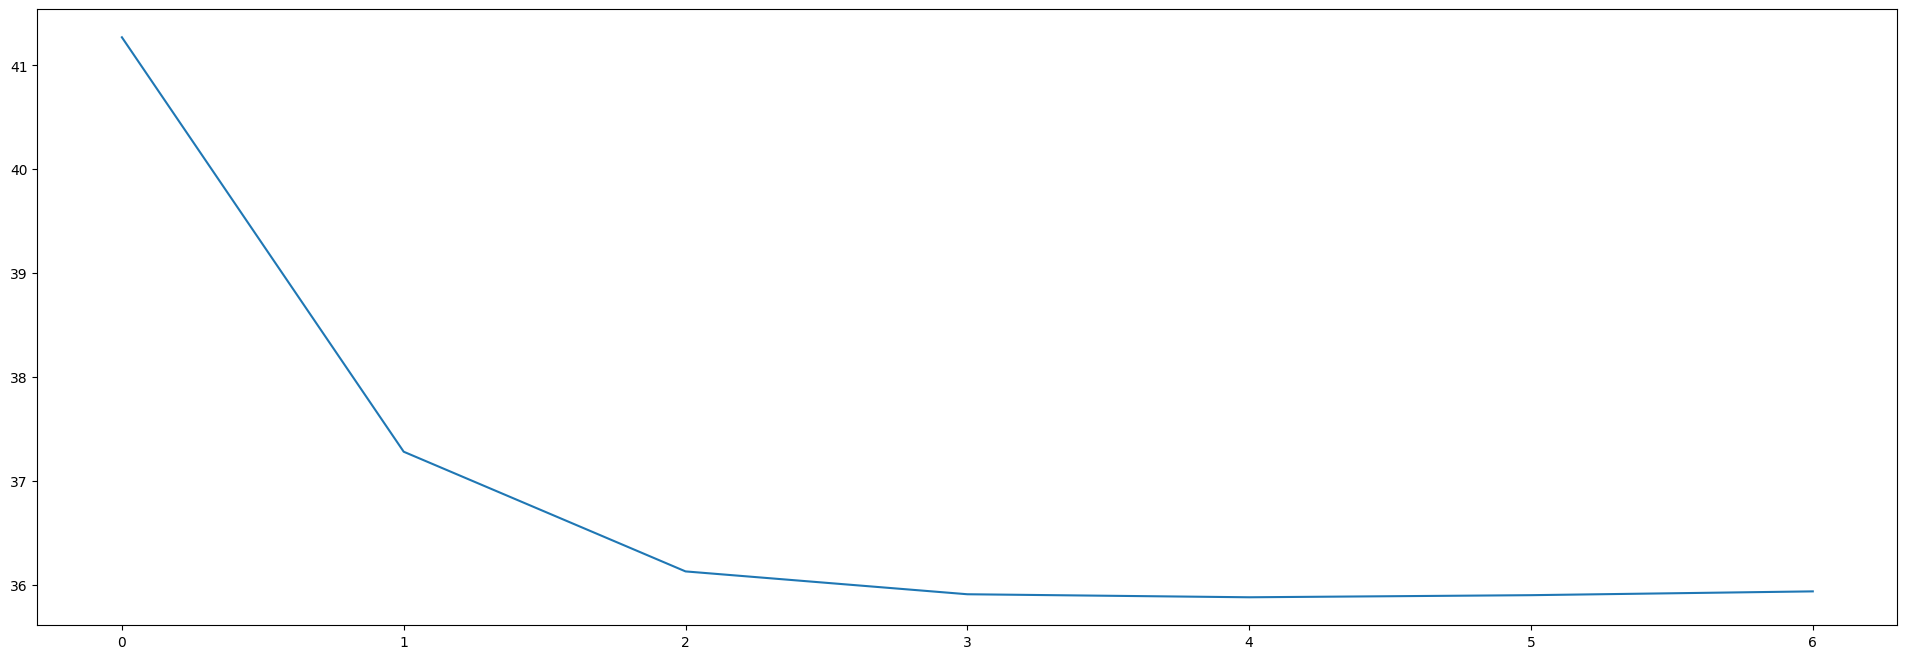

In [107]:
plt.figure(figsize=(24, 8))
plt.plot(range(len(future_30)), future_30)
print(future_30)

In [108]:
train_predicions=model2.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train.flatten()})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step


,Train Predictions,Actuals
0,43.796131,35.5
1,39.862972,29.0
2,38.769115,28.0
3,38.737484,35.5
4,38.866222,29.5
...,...,...
321995,35.123390,37.0
321996,35.001011,51.0
321997,35.022583,56.0
321998,35.078857,56.5


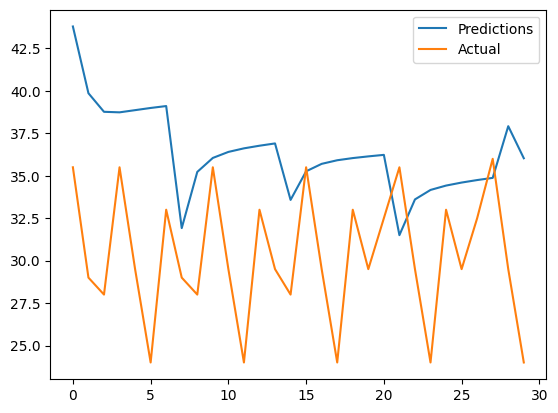

In [109]:
plt.plot(train_results["Train Predictions"][:30], label='Predictions')
plt.plot(train_results["Actuals"][:30], label='Actual')
plt.legend()


In [110]:
val_predicions=model2.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val.flatten()})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


,Validation Predictions,Actuals
0,28.928072,30.0
1,31.961599,37.0
2,32.741615,51.0
3,32.960159,56.0
4,33.076344,56.5
...,...,...
36045,38.357494,32.0
36046,38.459675,38.0
36047,38.550816,38.5
36048,38.620876,28.0


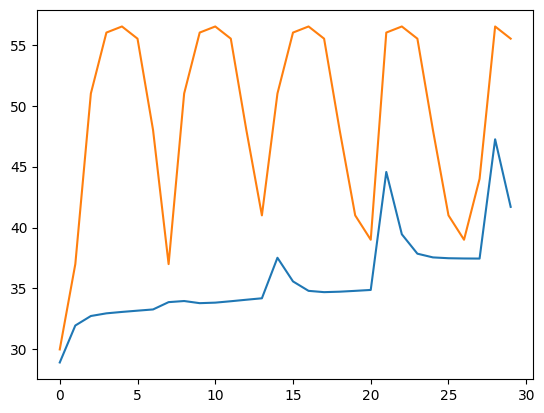

In [111]:
plt.plot(val_results["Validation Predictions"][:30])
plt.plot(val_results["Actuals"][:30])

In [112]:
test_predictions=model2.predict(X_test)
#print(test_predictions)
#test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test})
#print(test_predictions)


159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [113]:
print(test_predictions.shape)
print(y_test.shape)

(5058, 7, 1)
(5058, 7, 1)


Text(0.5, 1.0, '2022 Test Predictions vs Real Data')

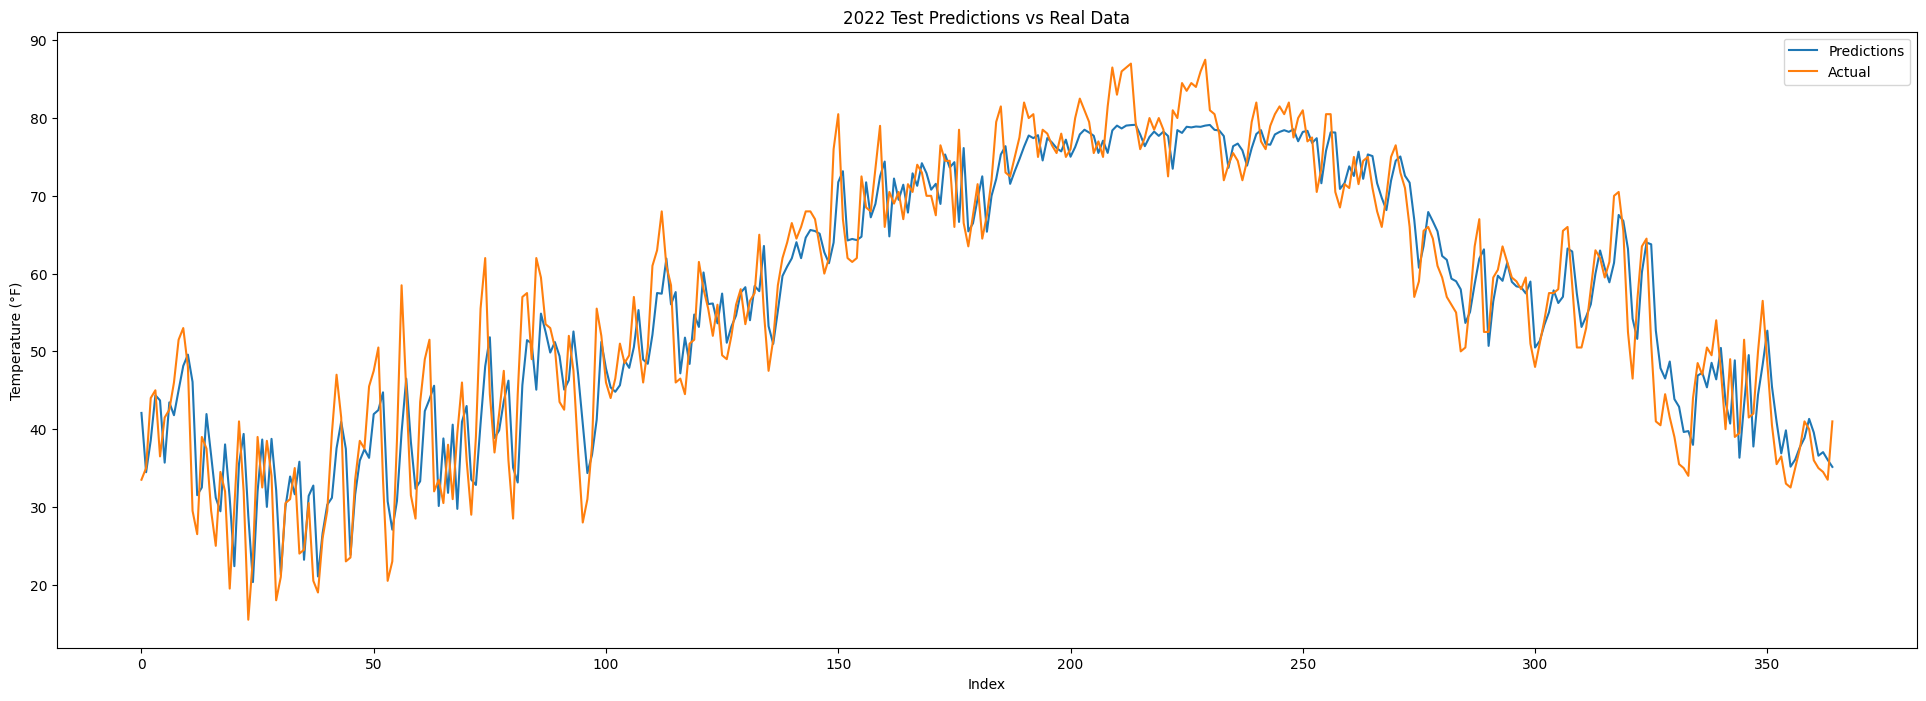

In [114]:
#preds = pd.Series(test_results["Test Predictions"][-365:]).shift(-1)
#print(preds.head())

preds=test_predictions[:, 0, 0]
actuals=y_test[:, 0, 0]
plt.figure(figsize=(24, 8))
plt.plot(preds[-365:], label='Predictions')
plt.plot(actuals[-365:], label='Actual')
plt.legend()
plt.xlabel("Index")
plt.ylabel('Temperature (\u00B0F)')
plt.title('2022 Test Predictions vs Real Data')



[ 2.93838501  4.15055084 -3.65748215  1.18695068  9.87287903]
Average Error:  -0.07701213994295808


C:\Users\fdram\AppData\Local\Temp\ipykernel_21024\710327918.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


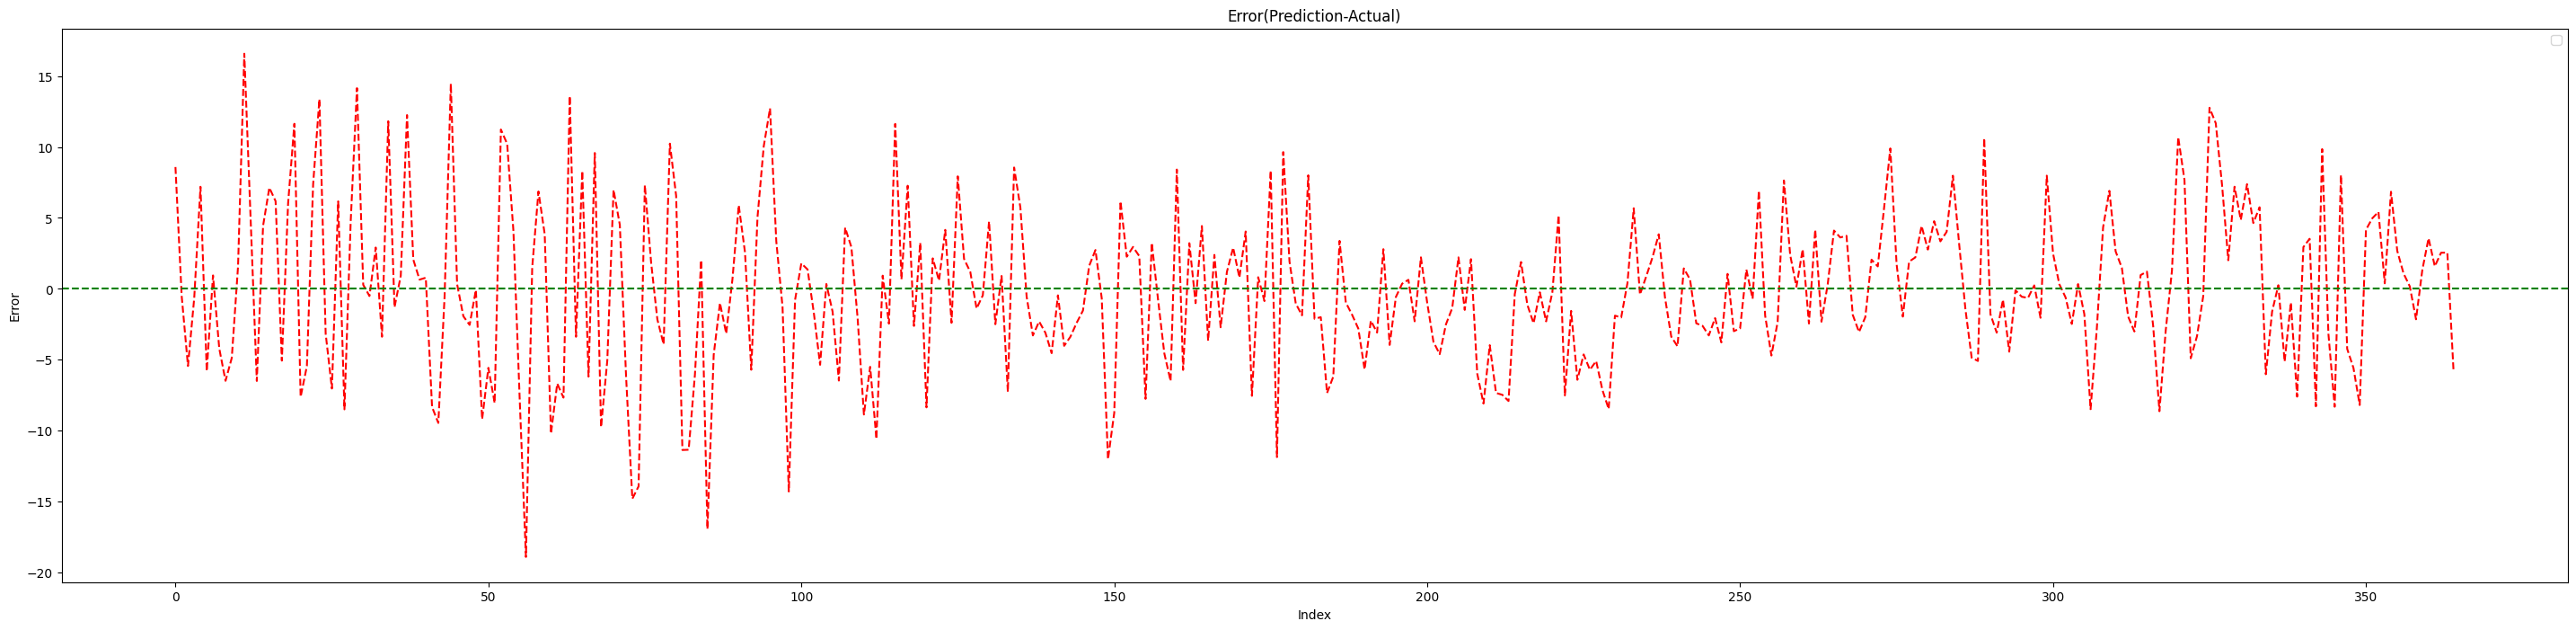

In [115]:
errors=preds-actuals
print(errors[:5])
avg_error=np.mean(errors)
print("Average Error: ", avg_error)
plt.figure(figsize=(36, 8))
plt.plot(errors[-365:], linestyle='dashed', color='red')
plt.axhline(0, linestyle='--', color='green')
plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Error(Prediction-Actual)')
plt.legend()

In [116]:
mae=mean_absolute_error(actuals, preds)
print("Mean Absolute Error= ", mae)

Mean Absolute Error=  4.211301201933125
